# Resampling and Algorithmic Solutions

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef
)

from imblearn.under_sampling import (
    RandomUnderSampler, TomekLinks, EditedNearestNeighbours
)
from imblearn.over_sampling import (
    RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
)
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb

# ── Load shared state from Chapter 8 ─────────────────────────────────────
_ch08_out = Path(DATA_PROCESSED)

X_cc_tr_sc = np.load(_ch08_out / 'X_cc_tr_sc.npy')
X_cc_te_sc = np.load(_ch08_out / 'X_cc_te_sc.npy')
X_mm_tr_sc = np.load(_ch08_out / 'X_mm_tr_sc.npy')
X_mm_te_sc = np.load(_ch08_out / 'X_mm_te_sc.npy')

y_cc_tr = pd.read_pickle(_ch08_out / 'y_cc_tr.pkl')
y_cc_te = pd.read_pickle(_ch08_out / 'y_cc_te.pkl')
y_mm_tr = pd.read_pickle(_ch08_out / 'y_mm_tr.pkl')
y_mm_te = pd.read_pickle(_ch08_out / 'y_mm_te.pkl')

print('Chapter 8 shared state loaded:')
print(f'  CC  train: {len(y_cc_tr):,} obs  |  test: {len(y_cc_te):,} obs')
print(f'  MM  train: {len(y_mm_tr):,} obs  |  test: {len(y_mm_te):,} obs')


def print_metrics(y_true, y_pred, y_prob, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{'─'*55}")
    print(f'  {label}')
    print(f"{'─'*55}")
    print(f'  Accuracy    : {accuracy_score(y_true, y_pred):.5f}')
    print(f'  Precision   : {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  Recall      : {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  F1 Score    : {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  MCC         : {matthews_corrcoef(y_true, y_pred):.4f}')
    if y_prob is not None:
        print(f'  ROC-AUC     : {roc_auc_score(y_true, y_prob):.4f}')
        print(f'  PR-AUC      : {average_precision_score(y_true, y_prob):.4f}')
    print(f'  Confusion   : TP={tp}, FP={fp}, FN={fn}, TN={tn}')


Chapter 8 shared state loaded:
  CC  train: 227,845 obs  |  test: 56,962 obs
  MM  train: 8,946 obs  |  test: 2,237 obs


## Undersampling Techniques

### Random Undersampling

In [2]:
# ── Random Undersampling ───────────────────────────────────────────────────
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_SEED)
X_rus, y_rus = rus.fit_resample(X_cc_tr_sc, y_cc_tr)

print(f"Original training set  : {len(y_cc_tr):,} obs, "
      f"{y_cc_tr.sum()} positive ({y_cc_tr.mean()*100:.3f}%)")
print(f"After random undersamp.: {len(y_rus):,} obs, "
      f"{y_rus.sum()} positive ({y_rus.mean()*100:.1f}%)")
print(f"  Majority retained    : {(y_rus==0).sum()} of {(y_cc_tr==0).sum():,} "
      f"({(y_rus==0).sum()/(y_cc_tr==0).sum()*100:.2f}%)")

# ── Fit LR on undersampled data ───────────────────────────────────────────
lr_rus = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_rus.fit(X_rus, y_rus)
y_rus_pred = lr_rus.predict(X_cc_te_sc)
y_rus_prob  = lr_rus.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_rus_pred, y_rus_prob, "LR + Random Undersampling (1:1)")

Original training set  : 227,845 obs, 394 positive (0.173%)
After random undersamp.: 788 obs, 394 positive (50.0%)
  Majority retained    : 394 of 227,451 (0.17%)

───────────────────────────────────────────────────────
  LR + Random Undersampling (1:1)
───────────────────────────────────────────────────────
  Accuracy    : 0.95846
  Precision   : 0.0368
  Recall      : 0.9184
  F1 Score    : 0.0707
  MCC         : 0.1792
  ROC-AUC     : 0.9764
  PR-AUC      : 0.6059
  Confusion   : TP=90, FP=2358, FN=8, TN=54506


### Tomek Links

In [3]:
# ── Tomek Links ───────────────────────────────────────────────────────────
tl = TomekLinks(sampling_strategy="majority")
X_tl, y_tl = tl.fit_resample(X_cc_tr_sc, y_cc_tr)

print(f"Original training set : {len(y_cc_tr):,} obs")
print(f"After Tomek Links     : {len(y_tl):,} obs "
      f"(removed {len(y_cc_tr)-len(y_tl):,} majority samples)")

lr_tl = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_tl.fit(X_tl, y_tl)
y_tl_pred = lr_tl.predict(X_cc_te_sc)
y_tl_prob  = lr_tl.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_tl_pred, y_tl_prob, "LR + Tomek Links")

Original training set : 227,845 obs
After Tomek Links     : 227,824 obs (removed 21 majority samples)

───────────────────────────────────────────────────────
  LR + Tomek Links
───────────────────────────────────────────────────────
  Accuracy    : 0.99917
  Precision   : 0.8312
  Recall      : 0.6531
  F1 Score    : 0.7314
  MCC         : 0.7364
  ROC-AUC     : 0.9587
  PR-AUC      : 0.7390
  Confusion   : TP=64, FP=13, FN=34, TN=56851


### Edited Nearest Neighbours

In [4]:
# ── Edited Nearest Neighbours ─────────────────────────────────────────────
enn = EditedNearestNeighbours(sampling_strategy="majority", n_neighbors=3)
X_enn, y_enn = enn.fit_resample(X_cc_tr_sc, y_cc_tr)

print(f"Original training set : {len(y_cc_tr):,} obs")
print(f"After ENN             : {len(y_enn):,} obs "
      f"(removed {len(y_cc_tr)-len(y_enn):,} majority samples)")

lr_enn = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_enn.fit(X_enn, y_enn)
y_enn_pred = lr_enn.predict(X_cc_te_sc)
y_enn_prob  = lr_enn.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_enn_pred, y_enn_prob, "LR + Edited Nearest Neighbours")

Original training set : 227,845 obs
After ENN             : 227,701 obs (removed 144 majority samples)

───────────────────────────────────────────────────────
  LR + Edited Nearest Neighbours
───────────────────────────────────────────────────────
  Accuracy    : 0.99923
  Precision   : 0.8375
  Recall      : 0.6837
  F1 Score    : 0.7528
  MCC         : 0.7563
  ROC-AUC     : 0.9665
  PR-AUC      : 0.7427
  Confusion   : TP=67, FP=13, FN=31, TN=56851


## Oversampling Techniques

### Random Oversampling

In [5]:
# ── Random Oversampling ───────────────────────────────────────────────────
ros = RandomOverSampler(sampling_strategy=1.0, random_state=RANDOM_SEED)
X_ros, y_ros = ros.fit_resample(X_cc_tr_sc, y_cc_tr)

print(f"Original training set  : {len(y_cc_tr):,} obs, {y_cc_tr.sum()} positive")
print(f"After random oversamp. : {len(y_ros):,} obs, {y_ros.sum()} positive")
print(f"  Minority replicated  : {y_ros.sum() - y_cc_tr.sum():,} synthetic copies added")

lr_ros = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_ros.fit(X_ros, y_ros)
y_ros_pred = lr_ros.predict(X_cc_te_sc)
y_ros_prob  = lr_ros.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_ros_pred, y_ros_prob, "LR + Random Oversampling (1:1)")

Original training set  : 227,845 obs, 394 positive
After random oversamp. : 454,902 obs, 227451 positive
  Minority replicated  : 227,057 synthetic copies added

───────────────────────────────────────────────────────
  LR + Random Oversampling (1:1)
───────────────────────────────────────────────────────
  Accuracy    : 0.97428
  Precision   : 0.0582
  Recall      : 0.9184
  F1 Score    : 0.1094
  MCC         : 0.2276
  ROC-AUC     : 0.9705
  PR-AUC      : 0.7079
  Confusion   : TP=90, FP=1457, FN=8, TN=55407


## Synthetic Minority Oversampling

### SMOTE

In [6]:
# ── SMOTE ─────────────────────────────────────────────────────────────────
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=RANDOM_SEED)
X_smote, y_smote = smote.fit_resample(X_cc_tr_sc, y_cc_tr)

print(f"Original training set  : {len(y_cc_tr):,} obs, {y_cc_tr.sum()} positive")
print(f"After SMOTE (1:1)      : {len(y_smote):,} obs, {y_smote.sum()} positive")
print(f"  Synthetic samples    : {y_smote.sum() - y_cc_tr.sum():,} generated")

lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_smote.fit(X_smote, y_smote)
y_smote_pred = lr_smote.predict(X_cc_te_sc)
y_smote_prob  = lr_smote.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_smote_pred, y_smote_prob, "LR + SMOTE (1:1)")

Original training set  : 227,845 obs, 394 positive
After SMOTE (1:1)      : 454,902 obs, 227451 positive
  Synthetic samples    : 227,057 generated

───────────────────────────────────────────────────────
  LR + SMOTE (1:1)
───────────────────────────────────────────────────────
  Accuracy    : 0.97309
  Precision   : 0.0557
  Recall      : 0.9184
  F1 Score    : 0.1051
  MCC         : 0.2226
  ROC-AUC     : 0.9701
  PR-AUC      : 0.7182
  Confusion   : TP=90, FP=1525, FN=8, TN=55339


### Visualising SMOTE Interpolation

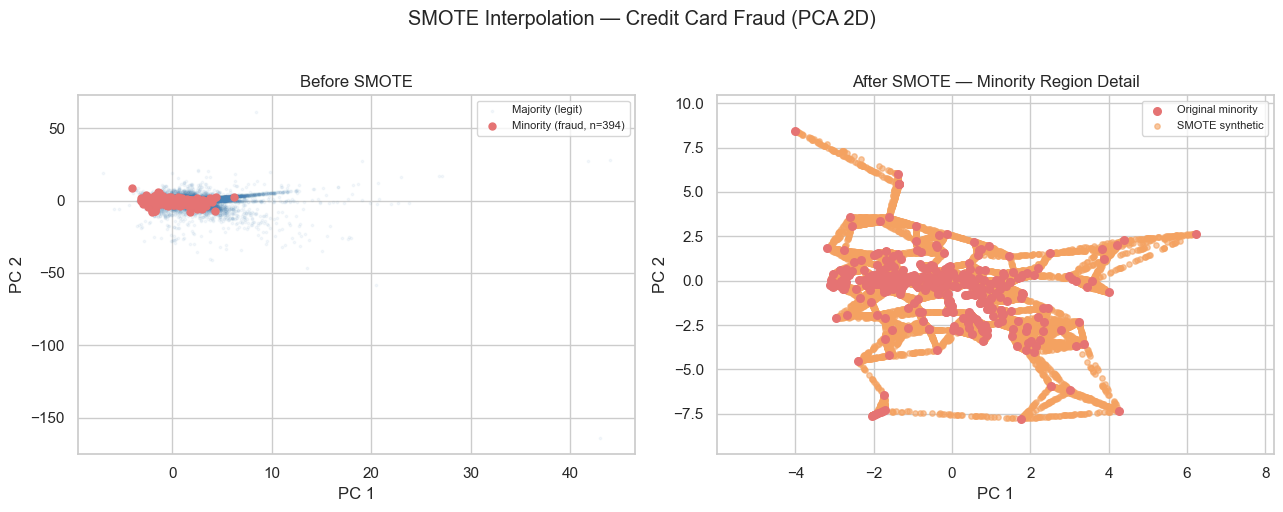

In [7]:
# ── 2D illustration of SMOTE on first two PCA components of fraud data ────
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=RANDOM_SEED)
X_tr_2d = pca_vis.fit_transform(X_cc_tr_sc)

# SMOTE on 2D projection for illustration only
smote_vis = SMOTE(sampling_strategy=0.2, k_neighbors=5, random_state=RANDOM_SEED)
X_vis_sm, y_vis_sm = smote_vis.fit_resample(X_tr_2d, y_cc_tr)

# Identify which points are original vs. synthetic
n_orig = len(y_cc_tr)
original_minority_mask  = (y_cc_tr.values == 1)
synthetic_mask = (y_vis_sm[n_orig:] == 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before SMOTE
ax = axes[0]
ax.scatter(X_tr_2d[y_cc_tr==0, 0], X_tr_2d[y_cc_tr==0, 1],
           c="steelblue", alpha=0.05, s=3, label="Majority (legit)")
ax.scatter(X_tr_2d[y_cc_tr==1, 0], X_tr_2d[y_cc_tr==1, 1],
           c="#E57373", s=25, zorder=5, label=f"Minority (fraud, n={y_cc_tr.sum()})")
ax.set_title("Before SMOTE")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(fontsize=8)

# After SMOTE — zoom into minority region
ax = axes[1]
X_syn_2d = X_vis_sm[n_orig:]
y_syn    = y_vis_sm[n_orig:]
ax.scatter(X_tr_2d[y_cc_tr==1, 0], X_tr_2d[y_cc_tr==1, 1],
           c="#E57373", s=30, zorder=5, label="Original minority")
ax.scatter(X_syn_2d[y_syn==1, 0], X_syn_2d[y_syn==1, 1],
           c="#F4A261", s=15, alpha=0.6, zorder=4, label="SMOTE synthetic")
x_min = X_tr_2d[y_cc_tr==1, 0].min() - 2
x_max = X_tr_2d[y_cc_tr==1, 0].max() + 2
y_min = X_tr_2d[y_cc_tr==1, 1].min() - 2
y_max = X_tr_2d[y_cc_tr==1, 1].max() + 2
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title("After SMOTE — Minority Region Detail")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(fontsize=8)

plt.suptitle("SMOTE Interpolation — Credit Card Fraud (PCA 2D)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch09_smote_viz.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Borderline-SMOTE ──────────────────────────────────────────────────────
bsmote = BorderlineSMOTE(
    sampling_strategy=1.0, k_neighbors=5,
    m_neighbors=10, kind="borderline-1",
    random_state=RANDOM_SEED
)
X_bsmote, y_bsmote = bsmote.fit_resample(X_cc_tr_sc, y_cc_tr)

lr_bsmote = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_bsmote.fit(X_bsmote, y_bsmote)
y_bsmote_pred = lr_bsmote.predict(X_cc_te_sc)
y_bsmote_prob  = lr_bsmote.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_bsmote_pred, y_bsmote_prob, "LR + Borderline-SMOTE")


───────────────────────────────────────────────────────
  LR + Borderline-SMOTE
───────────────────────────────────────────────────────
  Accuracy    : 0.98862
  Precision   : 0.1181
  Recall      : 0.8673
  F1 Score    : 0.2078
  MCC         : 0.3176
  ROC-AUC     : 0.9467
  PR-AUC      : 0.6835
  Confusion   : TP=85, FP=635, FN=13, TN=56229


### ADASYN

In [9]:
# ── ADASYN ────────────────────────────────────────────────────────────────
adasyn = ADASYN(sampling_strategy=1.0, n_neighbors=5, random_state=RANDOM_SEED)
X_ada, y_ada = adasyn.fit_resample(X_cc_tr_sc, y_cc_tr)

lr_ada = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_ada.fit(X_ada, y_ada)
y_ada_pred = lr_ada.predict(X_cc_te_sc)
y_ada_prob  = lr_ada.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_ada_pred, y_ada_prob, "LR + ADASYN")


───────────────────────────────────────────────────────
  LR + ADASYN
───────────────────────────────────────────────────────
  Accuracy    : 0.90938
  Precision   : 0.0173
  Recall      : 0.9286
  F1 Score    : 0.0341
  MCC         : 0.1201
  ROC-AUC     : 0.9724
  PR-AUC      : 0.7158
  Confusion   : TP=91, FP=5155, FN=7, TN=51709


## Algorithmic Adjustments

### Class Weights

In [10]:
# ── Class-weighted logistic regression ────────────────────────────────────
lr_cw = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
)
lr_cw.fit(X_cc_tr_sc, y_cc_tr)
y_cw_pred = lr_cw.predict(X_cc_te_sc)
y_cw_prob  = lr_cw.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_cw_pred, y_cw_prob, "LR + class_weight='balanced'")

# ── Class-weighted LightGBM ────────────────────────────────────────────────
scale_pos = (y_cc_tr == 0).sum() / (y_cc_tr == 1).sum()
lgb_cw = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_cw.fit(X_cc_tr_sc, y_cc_tr)
y_lgb_pred = lgb_cw.predict(X_cc_te_sc)
y_lgb_prob  = lgb_cw.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_lgb_pred, y_lgb_prob, "LightGBM + scale_pos_weight")


───────────────────────────────────────────────────────
  LR + class_weight='balanced'
───────────────────────────────────────────────────────
  Accuracy    : 0.97405
  Precision   : 0.0577
  Recall      : 0.9184
  F1 Score    : 0.1086
  MCC         : 0.2266
  ROC-AUC     : 0.9705
  PR-AUC      : 0.7078
  Confusion   : TP=90, FP=1470, FN=8, TN=55394

───────────────────────────────────────────────────────
  LightGBM + scale_pos_weight
───────────────────────────────────────────────────────
  Accuracy    : 0.97985
  Precision   : 0.0690
  Recall      : 0.8571
  F1 Score    : 0.1277
  MCC         : 0.2398
  ROC-AUC     : 0.9177
  PR-AUC      : 0.0615
  Confusion   : TP=84, FP=1134, FN=14, TN=55730


### Decision Threshold Tuning

Optimal threshold for F1 : 0.0543  (F1=0.7468)
Optimal threshold for F2 : 0.0297  (F2=0.7674)


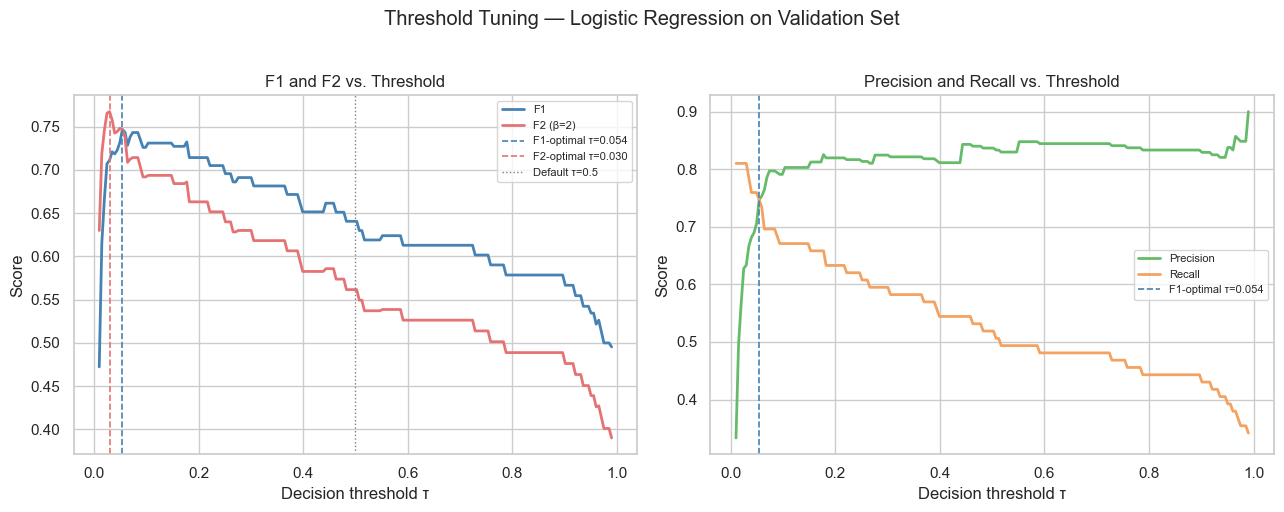


  Default τ=0.50
  TP=63, FP=13, FN=35, TN=56851 | F1=0.7241  F2=0.6731  MCC=0.7296

  F1-optimal τ=0.054
  TP=79, FP=42, FN=19, TN=56822 | F1=0.7215  F2=0.7700  MCC=0.7250

  F2-optimal τ=0.030
  TP=80, FP=57, FN=18, TN=56807 | F1=0.6809  F2=0.7561  MCC=0.6898


In [11]:
from sklearn.metrics import f1_score, fbeta_score

# ── Tune threshold for LR (vanilla model) on validation data ──────────────
# Use a dedicated validation set carved from the training data
X_fit, X_val, y_fit, y_val = train_test_split(
    X_cc_tr_sc, y_cc_tr, test_size=0.2,
    stratify=y_cc_tr, random_state=RANDOM_SEED
)

lr_thresh = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_thresh.fit(X_fit, y_fit)
val_probs = lr_thresh.predict_proba(X_val)[:, 1]

# ── Sweep thresholds and record F1 and F2 ────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)
f1_vals, f2_vals, prec_vals, rec_vals = [], [], [], []

for tau in thresholds:
    y_hat = (val_probs >= tau).astype(int)
    f1_vals.append(f1_score(y_val, y_hat, zero_division=0))
    f2_vals.append(fbeta_score(y_val, y_hat, beta=2, zero_division=0))
    prec_vals.append(precision_score(y_val, y_hat, zero_division=0))
    rec_vals.append(recall_score(y_val, y_hat, zero_division=0))

best_tau_f1 = thresholds[np.argmax(f1_vals)]
best_tau_f2 = thresholds[np.argmax(f2_vals)]

print(f"Optimal threshold for F1 : {best_tau_f1:.4f}  "
      f"(F1={max(f1_vals):.4f})")
print(f"Optimal threshold for F2 : {best_tau_f2:.4f}  "
      f"(F2={max(f2_vals):.4f})")

# ── Plot threshold sweep ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(thresholds, f1_vals, color="steelblue", lw=2, label="F1")
ax.plot(thresholds, f2_vals, color="#E57373",   lw=2, label="F2 (β=2)")
ax.axvline(best_tau_f1, color="steelblue", lw=1.2, linestyle="--",
           label=f"F1-optimal τ={best_tau_f1:.3f}")
ax.axvline(best_tau_f2, color="#E57373",   lw=1.2, linestyle="--",
           label=f"F2-optimal τ={best_tau_f2:.3f}")
ax.axvline(0.5, color="gray", lw=1, linestyle=":", label="Default τ=0.5")
ax.set_xlabel("Decision threshold τ")
ax.set_ylabel("Score")
ax.set_title("F1 and F2 vs. Threshold")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(thresholds, prec_vals, color="#66BB6A", lw=2, label="Precision")
ax.plot(thresholds, rec_vals,  color="#F4A261", lw=2, label="Recall")
ax.axvline(best_tau_f1, color="steelblue", lw=1.2, linestyle="--",
           label=f"F1-optimal τ={best_tau_f1:.3f}")
ax.set_xlabel("Decision threshold τ")
ax.set_ylabel("Score")
ax.set_title("Precision and Recall vs. Threshold")
ax.legend(fontsize=8)

plt.suptitle("Threshold Tuning — Logistic Regression on Validation Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch09_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Evaluate at tuned threshold on test set ───────────────────────────────
te_probs_thresh = lr_thresh.predict_proba(X_cc_te_sc)[:, 1]

for tau, label in [(0.50, "Default τ=0.50"),
                   (best_tau_f1, f"F1-optimal τ={best_tau_f1:.3f}"),
                   (best_tau_f2, f"F2-optimal τ={best_tau_f2:.3f}")]:
    y_hat = (te_probs_thresh >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_cc_te, y_hat).ravel()
    f1  = f1_score(y_cc_te, y_hat, zero_division=0)
    f2  = fbeta_score(y_cc_te, y_hat, beta=2, zero_division=0)
    mcc = matthews_corrcoef(y_cc_te, y_hat)
    print(f"\n  {label}")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn} | F1={f1:.4f}  F2={f2:.4f}  MCC={mcc:.4f}")

## Combining Resampling with Ensemble Methods

### BalancedRandomForest

In [12]:
from imblearn.ensemble import (
    BalancedRandomForestClassifier, EasyEnsembleClassifier,
    BalancedBaggingClassifier
)

# ── BalancedRandomForest ───────────────────────────────────────────────────
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    sampling_strategy="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
brf.fit(X_cc_tr_sc, y_cc_tr)
y_brf_pred = brf.predict(X_cc_te_sc)
y_brf_prob  = brf.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_brf_pred, y_brf_prob, "BalancedRandomForest (200 trees)")


───────────────────────────────────────────────────────
  BalancedRandomForest (200 trees)
───────────────────────────────────────────────────────
  Accuracy    : 0.97075
  Precision   : 0.0520
  Recall      : 0.9286
  F1 Score    : 0.0985
  MCC         : 0.2160
  ROC-AUC     : 0.9769
  PR-AUC      : 0.7680
  Confusion   : TP=91, FP=1659, FN=7, TN=55205


### EasyEnsemble

In [13]:
# ── EasyEnsemble ──────────────────────────────────────────────────────────
ee = EasyEnsembleClassifier(
    n_estimators=20,
    sampling_strategy="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
ee.fit(X_cc_tr_sc, y_cc_tr)
y_ee_pred = ee.predict(X_cc_te_sc)
y_ee_prob  = ee.predict_proba(X_cc_te_sc)[:, 1]

print_metrics(y_cc_te, y_ee_pred, y_ee_prob, "EasyEnsemble (20 estimators)")


───────────────────────────────────────────────────────
  EasyEnsemble (20 estimators)
───────────────────────────────────────────────────────
  Accuracy    : 0.96659
  Precision   : 0.0453
  Recall      : 0.9184
  F1 Score    : 0.0864
  MCC         : 0.2000
  ROC-AUC     : 0.9747
  PR-AUC      : 0.7571
  Confusion   : TP=90, FP=1895, FN=8, TN=54969


## A Systematic Comparison

### Full Results Table

In [14]:
# ── Compile all results on the test set ───────────────────────────────────
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_cc_tr_sc, y_cc_tr)
y_dummy = dummy.predict(X_cc_te_sc)

def get_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "MCC":       matthews_corrcoef(y_true, y_pred),
        "PR-AUC":    average_precision_score(y_true, y_prob),
        "TP": tp, "FP": fp, "FN": fn
    }

# Vanilla LR (from Chapter 8)
lr_vanilla = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_vanilla.fit(X_cc_tr_sc, y_cc_tr)
y_lr_pred = lr_vanilla.predict(X_cc_te_sc)
y_lr_prob  = lr_vanilla.predict_proba(X_cc_te_sc)[:, 1]

results = {
    "Majority-class baseline":          get_metrics(y_cc_te, y_dummy, np.zeros(len(y_cc_te))),
    "LR — vanilla":                     get_metrics(y_cc_te, y_lr_pred,      y_lr_prob),
    "LR — random undersample":          get_metrics(y_cc_te, y_rus_pred,     y_rus_prob),
    "LR — Tomek Links":                 get_metrics(y_cc_te, y_tl_pred,      y_tl_prob),
    "LR — ENN":                         get_metrics(y_cc_te, y_enn_pred,     y_enn_prob),
    "LR — random oversample":           get_metrics(y_cc_te, y_ros_pred,     y_ros_prob),
    "LR — SMOTE":                       get_metrics(y_cc_te, y_smote_pred,   y_smote_prob),
    "LR — Borderline-SMOTE":            get_metrics(y_cc_te, y_bsmote_pred,  y_bsmote_prob),
    "LR — ADASYN":                      get_metrics(y_cc_te, y_ada_pred,     y_ada_prob),
    "LR — class_weight=balanced":       get_metrics(y_cc_te, y_cw_pred,      y_cw_prob),
    "LR — threshold tuned (F1)":        get_metrics(y_cc_te,
                                            (te_probs_thresh >= best_tau_f1).astype(int),
                                            te_probs_thresh),
    "LightGBM — scale_pos_weight":      get_metrics(y_cc_te, y_lgb_pred,     y_lgb_prob),
    "BalancedRandomForest":             get_metrics(y_cc_te, y_brf_pred,     y_brf_prob),
    "EasyEnsemble":                     get_metrics(y_cc_te, y_ee_pred,      y_ee_prob),
}

res_df = pd.DataFrame(results).T
res_df = res_df[["Precision", "Recall", "F1", "MCC", "PR-AUC", "TP", "FP", "FN"]]

print(f"\n{'Strategy':<40}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'MCC':>6}  {'PR-AUC':>7}  {'TP':>3} {'FP':>4} {'FN':>3}")
print("─" * 95)
for name, row in res_df.iterrows():
    print(f"{name:<40}  {row['Precision']:>6.4f}  {row['Recall']:>6.4f}  "
          f"{row['F1']:>6.4f}  {row['MCC']:>6.4f}  {row['PR-AUC']:>7.4f}  "
          f"{int(row['TP']):>3} {int(row['FP']):>4} {int(row['FN']):>3}")


Strategy                                    Prec     Rec      F1     MCC   PR-AUC   TP   FP  FN
───────────────────────────────────────────────────────────────────────────────────────────────
Majority-class baseline                   0.0000  0.0000  0.0000  0.0000   0.0017    0    0  98
LR — vanilla                              0.8312  0.6531  0.7314  0.7364   0.7376   64   13  34
LR — random undersample                   0.0368  0.9184  0.0707  0.1792   0.6059   90 2358   8
LR — Tomek Links                          0.8312  0.6531  0.7314  0.7364   0.7390   64   13  34
LR — ENN                                  0.8375  0.6837  0.7528  0.7563   0.7427   67   13  31
LR — random oversample                    0.0582  0.9184  0.1094  0.2276   0.7079   90 1457   8
LR — SMOTE                                0.0557  0.9184  0.1051  0.2226   0.7182   90 1525   8
LR — Borderline-SMOTE                     0.1181  0.8673  0.2078  0.3176   0.6835   85  635  13
LR — ADASYN                            

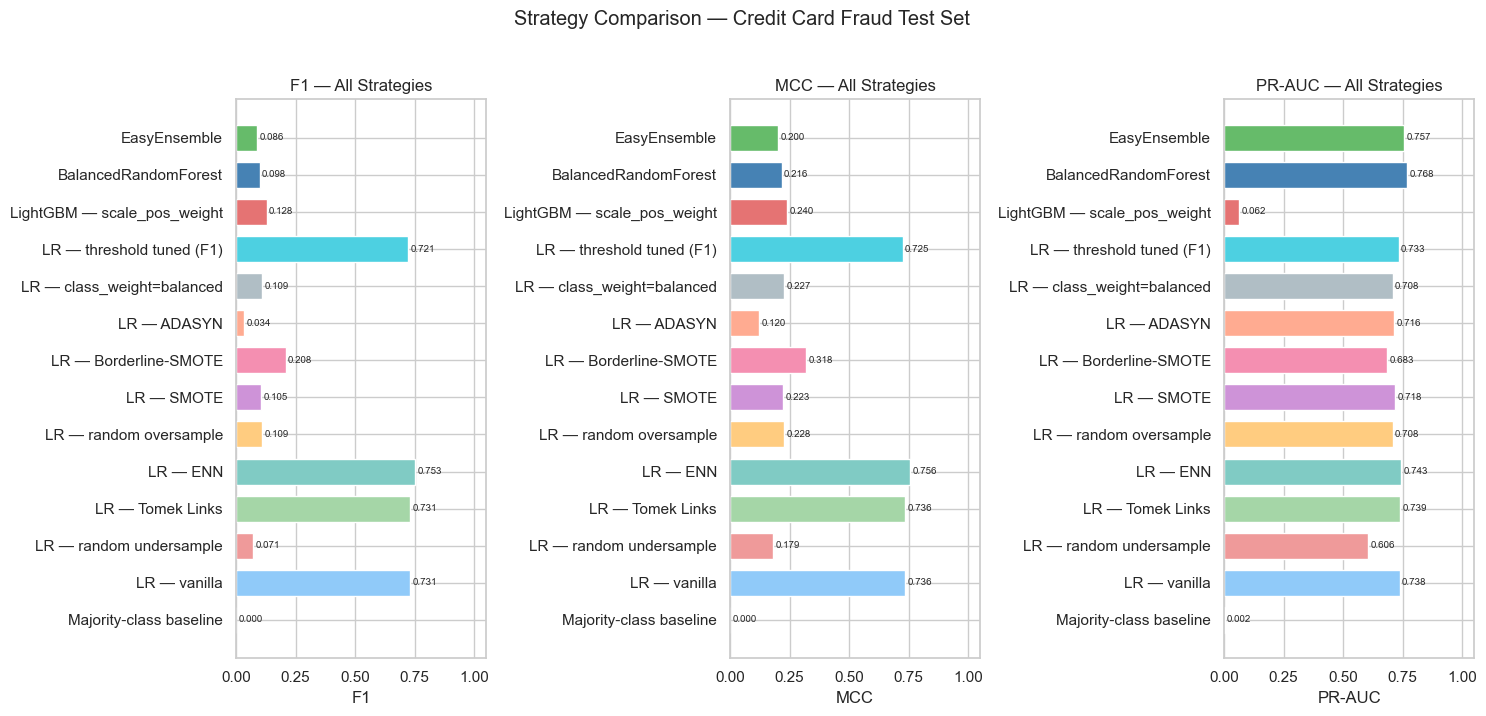

In [15]:
# ── Visual comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

metrics_plot = ["F1", "MCC", "PR-AUC"]
colors_map = {
    "Majority-class baseline": "#BBBBBB",
    "LR — vanilla":            "#90CAF9",
    "LR — random undersample": "#EF9A9A",
    "LR — Tomek Links":        "#A5D6A7",
    "LR — ENN":                "#80CBC4",
    "LR — random oversample":  "#FFCC80",
    "LR — SMOTE":              "#CE93D8",
    "LR — Borderline-SMOTE":   "#F48FB1",
    "LR — ADASYN":             "#FFAB91",
    "LR — class_weight=balanced": "#B0BEC5",
    "LR — threshold tuned (F1)":  "#4DD0E1",
    "LightGBM — scale_pos_weight": "#E57373",
    "BalancedRandomForest":    "steelblue",
    "EasyEnsemble":            "#66BB6A",
}

for ax, metric in zip(axes, metrics_plot):
    vals  = res_df[metric].values
    names = res_df.index.tolist()
    cols  = [colors_map[n] for n in names]
    bars  = ax.barh(names, vals, color=cols, edgecolor="white", height=0.7)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} — All Strategies")
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=7)

plt.suptitle("Strategy Comparison — Credit Card Fraud Test Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch09_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Application to the Mammography Dataset

In [16]:
# ── Apply best strategies to Mammography (42:1 imbalance, medical context) ─
mammo_results = {}

for name, (X_tr, y_tr, model) in {
    "LR vanilla": (
        X_mm_tr_sc, y_mm_tr,
        LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    ),
    "LR + SMOTE": (
        *SMOTE(sampling_strategy=1.0, random_state=RANDOM_SEED).fit_resample(X_mm_tr_sc, y_mm_tr),
        LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    ),
    "LR + ADASYN": (
        *ADASYN(sampling_strategy=1.0, random_state=RANDOM_SEED).fit_resample(X_mm_tr_sc, y_mm_tr),
        LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    ),
    "LightGBM + scale_pos_weight": (
        X_mm_tr_sc, y_mm_tr,
        lgb.LGBMClassifier(
            scale_pos_weight=(y_mm_tr==0).sum()/(y_mm_tr==1).sum(),
            n_estimators=300, learning_rate=0.05,
            random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
        )
    ),
    "BalancedRandomForest": (
        X_mm_tr_sc, y_mm_tr,
        BalancedRandomForestClassifier(
            n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1
        )
    ),
}.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_mm_te_sc)
    y_prob = model.predict_proba(X_mm_te_sc)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_mm_te, y_pred).ravel()
    mammo_results[name] = {
        "F1":    f1_score(y_mm_te, y_pred, zero_division=0),
        "F2":    fbeta_score(y_mm_te, y_pred, beta=2, zero_division=0),
        "MCC":   matthews_corrcoef(y_mm_te, y_pred),
        "PR-AUC": average_precision_score(y_mm_te, y_prob),
        "Recall": recall_score(y_mm_te, y_pred, zero_division=0),
        "TP": tp, "FN": fn
    }

mammo_df = pd.DataFrame(mammo_results).T
print("\nMammography Results (52 malignant in test set):")
print(f"\n{'Strategy':<35}  {'F1':>6}  {'F2':>6}  {'MCC':>6}  {'Recall':>7}  {'PR-AUC':>7}  {'TP':>3}/{52:>3}  {'FN':>3}")
print("─" * 90)
for name, row in mammo_df.iterrows():
    print(f"{name:<35}  {row['F1']:>6.4f}  {row['F2']:>6.4f}  {row['MCC']:>6.4f}  "
          f"{row['Recall']:>7.4f}  {row['PR-AUC']:>7.4f}  "
          f"{int(row['TP']):>3}/{52:>3}  {int(row['FN']):>3}")


Mammography Results (52 malignant in test set):

Strategy                                 F1      F2     MCC   Recall   PR-AUC   TP/ 52   FN
──────────────────────────────────────────────────────────────────────────────────────────
LR vanilla                           0.4935  0.4077  0.5198   0.3654   0.6513   19/ 52   33
LR + SMOTE                           0.3257  0.5400  0.4114   0.9615   0.6069   50/ 52    2
LR + ADASYN                          0.2112  0.3991  0.3083   0.9808   0.5306   51/ 52    1
LightGBM + scale_pos_weight          0.7573  0.7529  0.7516   0.7500   0.7765   39/ 52   13
BalancedRandomForest                 0.4974  0.6877  0.5460   0.9231   0.7556   48/ 52    4


### Decision Framework

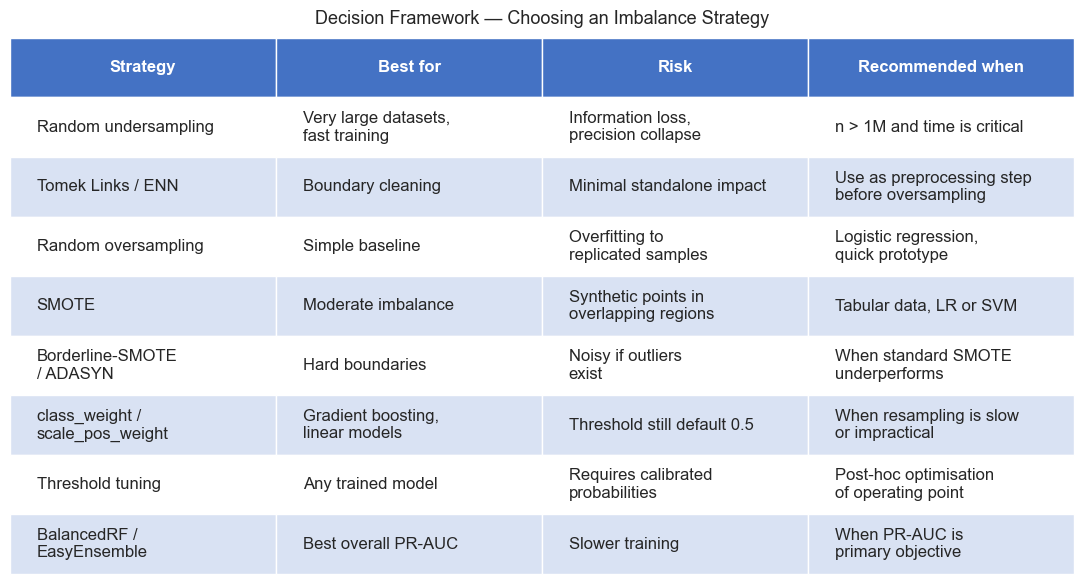

In [19]:
# ── Summary decision framework visualisation ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")

table_data = [
    ["Strategy", "Best for", "Risk", "Recommended when"],
    ["Random undersampling", "Very large datasets,\nfast training",
     "Information loss,\nprecision collapse", "n > 1M and time is critical"],
    ["Tomek Links / ENN", "Boundary cleaning", "Minimal standalone impact",
     "Use as preprocessing step\nbefore oversampling"],
    ["Random oversampling", "Simple baseline", "Overfitting to\nreplicated samples",
     "Logistic regression,\nquick prototype"],
    ["SMOTE", "Moderate imbalance", "Synthetic points in\noverlapping regions",
     "Tabular data, LR or SVM"],
    ["Borderline-SMOTE\n/ ADASYN", "Hard boundaries", "Noisy if outliers\nexist",
     "When standard SMOTE\nunderperforms"],
    ["class_weight / \nscale_pos_weight", "Gradient boosting,\nlinear models",
     "Threshold still default 0.5", "When resampling is slow\nor impractical"],
    ["Threshold tuning", "Any trained model", "Requires calibrated\nprobabilities",
     "Post-hoc optimisation\nof operating point"],
    ["BalancedRF /\nEasyEnsemble", "Best overall PR-AUC", "Slower training",
     "When PR-AUC is\nprimary objective"],
]

tbl = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc="left", loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#D9E2F3")
    cell.set_edgecolor("white")

ax.set_title("Decision Framework — Choosing an Imbalance Strategy",
             fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(FIGURES / "ch09_decision_framework.png", dpi=150, bbox_inches="tight")
plt.show()